In [1]:
#   PHASE 5 — EVALUATION + EXPLAINABILITY                         
#   Comprehensive metrics, ROC/PR curves, confusion matrices,     
#   SHAP explainability, per-attack analysis, radar charts        

!pip install shap scikit-learn pandas numpy matplotlib seaborn scipy -q

import os, pickle, warnings, json
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import matplotlib.patches   as mpatches
import matplotlib.ticker    as ticker
import seaborn              as sns
import shap

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix,
    matthews_corrcoef, roc_curve,
    precision_recall_curve, average_precision_score,
)

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.width', 220)

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'figure.dpi'       : 120,
})

LAYER_COLORS = {
    'physical'    : '#2196F3',
    'network'     : '#FF9800',
    'control'     : '#4CAF50',
    'supervisory' : '#9C27B0',
    'process'     : '#F44336',
}
LAYERS = ['physical', 'network', 'control', 'supervisory', 'process']

MODEL_COLORS = {
    'BiLSTM-AE Physical'    : '#2196F3',
    'BiLSTM-AE Network'     : '#FF9800',
    'BiLSTM-AE Control'     : '#4CAF50',
    'BiLSTM-AE Supervisory' : '#9C27B0',
    'BiLSTM-AE Process'     : '#F44336',
    'VAE'                   : '#607D8B',
    'TCN-AE'                : '#795548',
    'IForest Physical'      : '#42A5F5',
    'IForest Network'       : '#FFA726',
    'IForest Control'       : '#66BB6A',
    'IForest Supervisory'   : '#AB47BC',
    'IForest Process'       : '#EF5350',
    'Ensemble-Stacking-LR'  : '#000000',
}

# ── Paths ─────────────────────────────────────────────────────────
P1  = '/kaggle/input/notebooks/jaytalwar2005/ctmas-phase1/processed'
P3  = '/kaggle/input/notebooks/jaytalwar2005/ctmas-phase3/processed'
P3M = '/kaggle/input/notebooks/jaytalwar2005/ctmas-phase3/models'
P4  = '/kaggle/input/notebooks/jaytalwar2005/ctmas-phase4/processed'
OUT = '/kaggle/working/'

for d in [f'{OUT}/figures', f'{OUT}/processed']:
    os.makedirs(d, exist_ok=True)

# ── Verify inputs ─────────────────────────────────────────────────
checks = [
    (f'{P1}/layer_map.json',              'Phase1 layer map'),
    (f'{P1}/phase1_config.json',          'Phase1 config'),
    (f'{P3}/all_model_scores.csv',        'Phase3 all scores'),
    (f'{P3}/model_comparison.csv',        'Phase3 model comparison'),
    (f'{P3}/phase3_config.json',          'Phase3 config'),
    (f'{P3M}/iforest/shap_values.pkl',   'SHAP values'),
    (f'{P4}/drift_events.csv',            'Phase4 drift events'),
    (f'{P4}/phase4_config.json',          'Phase4 config'),
]
all_ok = True
print('Verifying inputs...')
for path, name in checks:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024**2 if exists else 0
    print(f'  {"Yes" if exists else "MISSING"}  {name:<35} {size:6.1f} MB')
    if not exists: all_ok = False

print(f'\n  All OK : {all_ok}')
print('\n Phase 5 setup complete')

Verifying inputs...
  Yes  Phase1 layer map                       0.0 MB
  Yes  Phase1 config                          0.0 MB
  Yes  Phase3 all scores                     27.5 MB
  Yes  Phase3 model comparison                0.0 MB
  Yes  Phase3 config                          0.0 MB
  Yes  SHAP values                            1.5 MB
  Yes  Phase4 drift events                    0.0 MB
  Yes  Phase4 config                          0.0 MB

  All OK : True

 Phase 5 setup complete


In [2]:
#   CELL 2 — Load All Outputs + Define Evaluation Helpers         
print('Loading all phase outputs.')

with open(f'{P1}/layer_map.json')     as f: LAYER_MAP = json.load(f)
with open(f'{P1}/phase1_config.json') as f: P1_CFG   = json.load(f)
with open(f'{P3}/phase3_config.json') as f: P3_CFG   = json.load(f)
with open(f'{P4}/phase4_config.json') as f: P4_CFG   = json.load(f)

scores_df    = pd.read_csv(f'{P3}/all_model_scores.csv', low_memory=False)
model_cmp_df = pd.read_csv(f'{P3}/model_comparison.csv')
drift_df     = pd.read_csv(f'{P4}/drift_events.csv')

with open(f'{P3M}/iforest/shap_values.pkl', 'rb') as f:
    shap_dict = pickle.load(f)

# ── Ground truth + predictions ────────────────────────────────────
y_true         = scores_df['y_true'].values.astype(np.int32)
ensemble_score = scores_df['ensemble_score'].values.astype(np.float64)
ensemble_pred  = scores_df['ensemble_pred'].values.astype(np.int32)
n_stream       = len(scores_df)
n_attack       = int(y_true.sum())
n_normal       = n_stream - n_attack

# All individual model score columns
SCORE_COLS = {
    'BiLSTM-AE Physical'    : 'bilstm_physical',
    'BiLSTM-AE Network'     : 'bilstm_network',
    'BiLSTM-AE Control'     : 'bilstm_control',
    'BiLSTM-AE Supervisory' : 'bilstm_supervisory',
    'BiLSTM-AE Process'     : 'bilstm_process',
    'VAE'                   : 'vae',
    'TCN-AE'                : 'tcn',
    'IForest Physical'      : 'iforest_physical',
    'IForest Network'       : 'iforest_network',
    'IForest Control'       : 'iforest_control',
    'IForest Supervisory'   : 'iforest_supervisory',
    'IForest Process'       : 'iforest_process',
}

# Keep only columns that exist in scores_df
SCORE_COLS = {k: v for k, v in SCORE_COLS.items() if v in scores_df.columns}

# Load all scores
model_scores = {
    name: scores_df[col].values.astype(np.float64)
    for name, col in SCORE_COLS.items()
}
model_scores['Ensemble-Stacking-LR'] = ensemble_score

print(f'  Stream       : {n_stream:,} samples')
print(f'  Attacks      : {n_attack:,} ({n_attack/n_stream*100:.1f}%)')
print(f'  Normal       : {n_normal:,}')
print(f'  Models loaded: {len(model_scores)}')
print(f'  SHAP layers  : {list(shap_dict.keys())}')
print(f'  Drift events : {len(drift_df)}')

# ── Evaluation helpers
def find_best_f1_threshold(scores, y_true):
    """F1-maximising threshold via precision-recall sweep."""
    from sklearn.metrics import precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    best_idx  = np.argmax(f1_scores)
    return float(thresholds[min(best_idx, len(thresholds)-1)])

def full_eval(scores, y_true, name=''):
    """Compute all metrics at F1-optimal threshold."""
    thresh = find_best_f1_threshold(scores, y_true)
    preds  = (scores >= thresh).astype(int)
    cm     = confusion_matrix(y_true, preds)
    TP = int(cm[1,1]); TN = int(cm[0,0])
    FP = int(cm[0,1]); FN = int(cm[1,0])
    return {
        'model'     : name,
        'threshold' : round(thresh, 6),
        'f1'        : round(f1_score(y_true, preds, zero_division=0), 4),
        'precision' : round(precision_score(y_true, preds, zero_division=0), 4),
        'recall'    : round(recall_score(y_true, preds, zero_division=0), 4),
        'auc'       : round(roc_auc_score(y_true, scores), 4),
        'ap'        : round(average_precision_score(y_true, scores), 4),
        'mcc'       : round(matthews_corrcoef(y_true, preds), 4),
        'fpr'       : round(FP / max(FP+TN,1), 4),
        'tpr'       : round(TP / max(TP+FN,1), 4),
        'tp': TP, 'tn': TN, 'fp': FP, 'fn': FN,
        'preds': preds,
    }

print('\n All data loaded and helpers defined')

Loading all phase outputs.
  Stream       : 188,953 samples
  Attacks      : 9,727 (5.1%)
  Normal       : 179,226
  Models loaded: 13
  SHAP layers  : ['physical', 'network', 'control', 'supervisory', 'process']
  Drift events : 14

 All data loaded and helpers defined


In [3]:
#   CELL 3 — Full Evaluation: All Models × All Metrics            

print('Computing full evaluation for all models.')
print()

eval_results = {}
for name, scores in model_scores.items():
    eval_results[name] = full_eval(scores, y_true, name)

# Build results table
eval_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'preds'}
    for r in eval_results.values()
]).sort_values('f1', ascending=False).reset_index(drop=True)

# Model type column
def model_type(name):
    if 'Ensemble' in name: return 'Ensemble'
    if 'BiLSTM' in name:   return 'BiLSTM-AE'
    if 'IForest' in name:  return 'IForest'
    if 'TCN' in name:      return 'TCN-AE'
    return 'VAE'

eval_df['type'] = eval_df['model'].apply(model_type)

print()
print('  PHASE 5 — COMPLETE EVALUATION TABLE')
print()
display_cols = ['model','f1','precision','recall','auc','ap','mcc','fpr','tpr','tp','fp','fn']
print(eval_df[display_cols].to_string(index=False))
print()

# Highlight best
best_f1  = eval_df.loc[eval_df['f1'].idxmax()]
best_auc = eval_df.loc[eval_df['auc'].idxmax()]
best_mcc = eval_df.loc[eval_df['mcc'].idxmax()]

print(f'  Best F1   : {best_f1["model"]:<30} F1={best_f1["f1"]:.4f}')
print(f'  Best AUC  : {best_auc["model"]:<30} AUC={best_auc["auc"]:.4f}')
print(f'  Best MCC  : {best_mcc["model"]:<30} MCC={best_mcc["mcc"]:.4f}')
print()

# Ensemble improvement over best individual
indiv_df  = eval_df[eval_df['type'] != 'Ensemble']
ens_row   = eval_df[eval_df['type'] == 'Ensemble'].iloc[0]
best_indiv_f1 = indiv_df['f1'].max()
print(f'  Ensemble F1 improvement over best individual: '
      f'+{(ens_row["f1"] - best_indiv_f1)*100:.1f} F1 points')

Computing full evaluation for all models.


  PHASE 5 — COMPLETE EVALUATION TABLE

                model     f1  precision  recall    auc     ap    mcc    fpr    tpr   tp   fp   fn
 Ensemble-Stacking-LR 0.6409     0.5853  0.7082 0.9300 0.5193 0.6226 0.0272 0.7082 6889 4881 2838
               TCN-AE 0.5408     0.8458  0.3975 0.8431 0.5061 0.5660 0.0039 0.3975 3866  705 5861
   BiLSTM-AE Physical 0.5348     0.8011  0.4014 0.8222 0.5234 0.5520 0.0054 0.4014 3904  969 5823
BiLSTM-AE Supervisory 0.5045     0.7166  0.3893 0.8858 0.3792 0.5106 0.0084 0.3893 3787 1498 5940
    BiLSTM-AE Process 0.4898     0.9402  0.3311 0.7784 0.4548 0.5465 0.0011 0.3311 3221  205 6506
     IForest Physical 0.4891     0.8474  0.3438 0.7475 0.4245 0.5261 0.0034 0.3438 3344  602 6383
  IForest Supervisory 0.4723     0.6366  0.3753 0.7477 0.2490 0.4685 0.0116 0.3753 3651 2084 6076
                  VAE 0.4624     0.8866  0.3127 0.6798 0.3770 0.5140 0.0022 0.3127 3042  389 6685
    BiLSTM-AE Network 0.4571     0.

Generating Figure 18 — ROC curves.


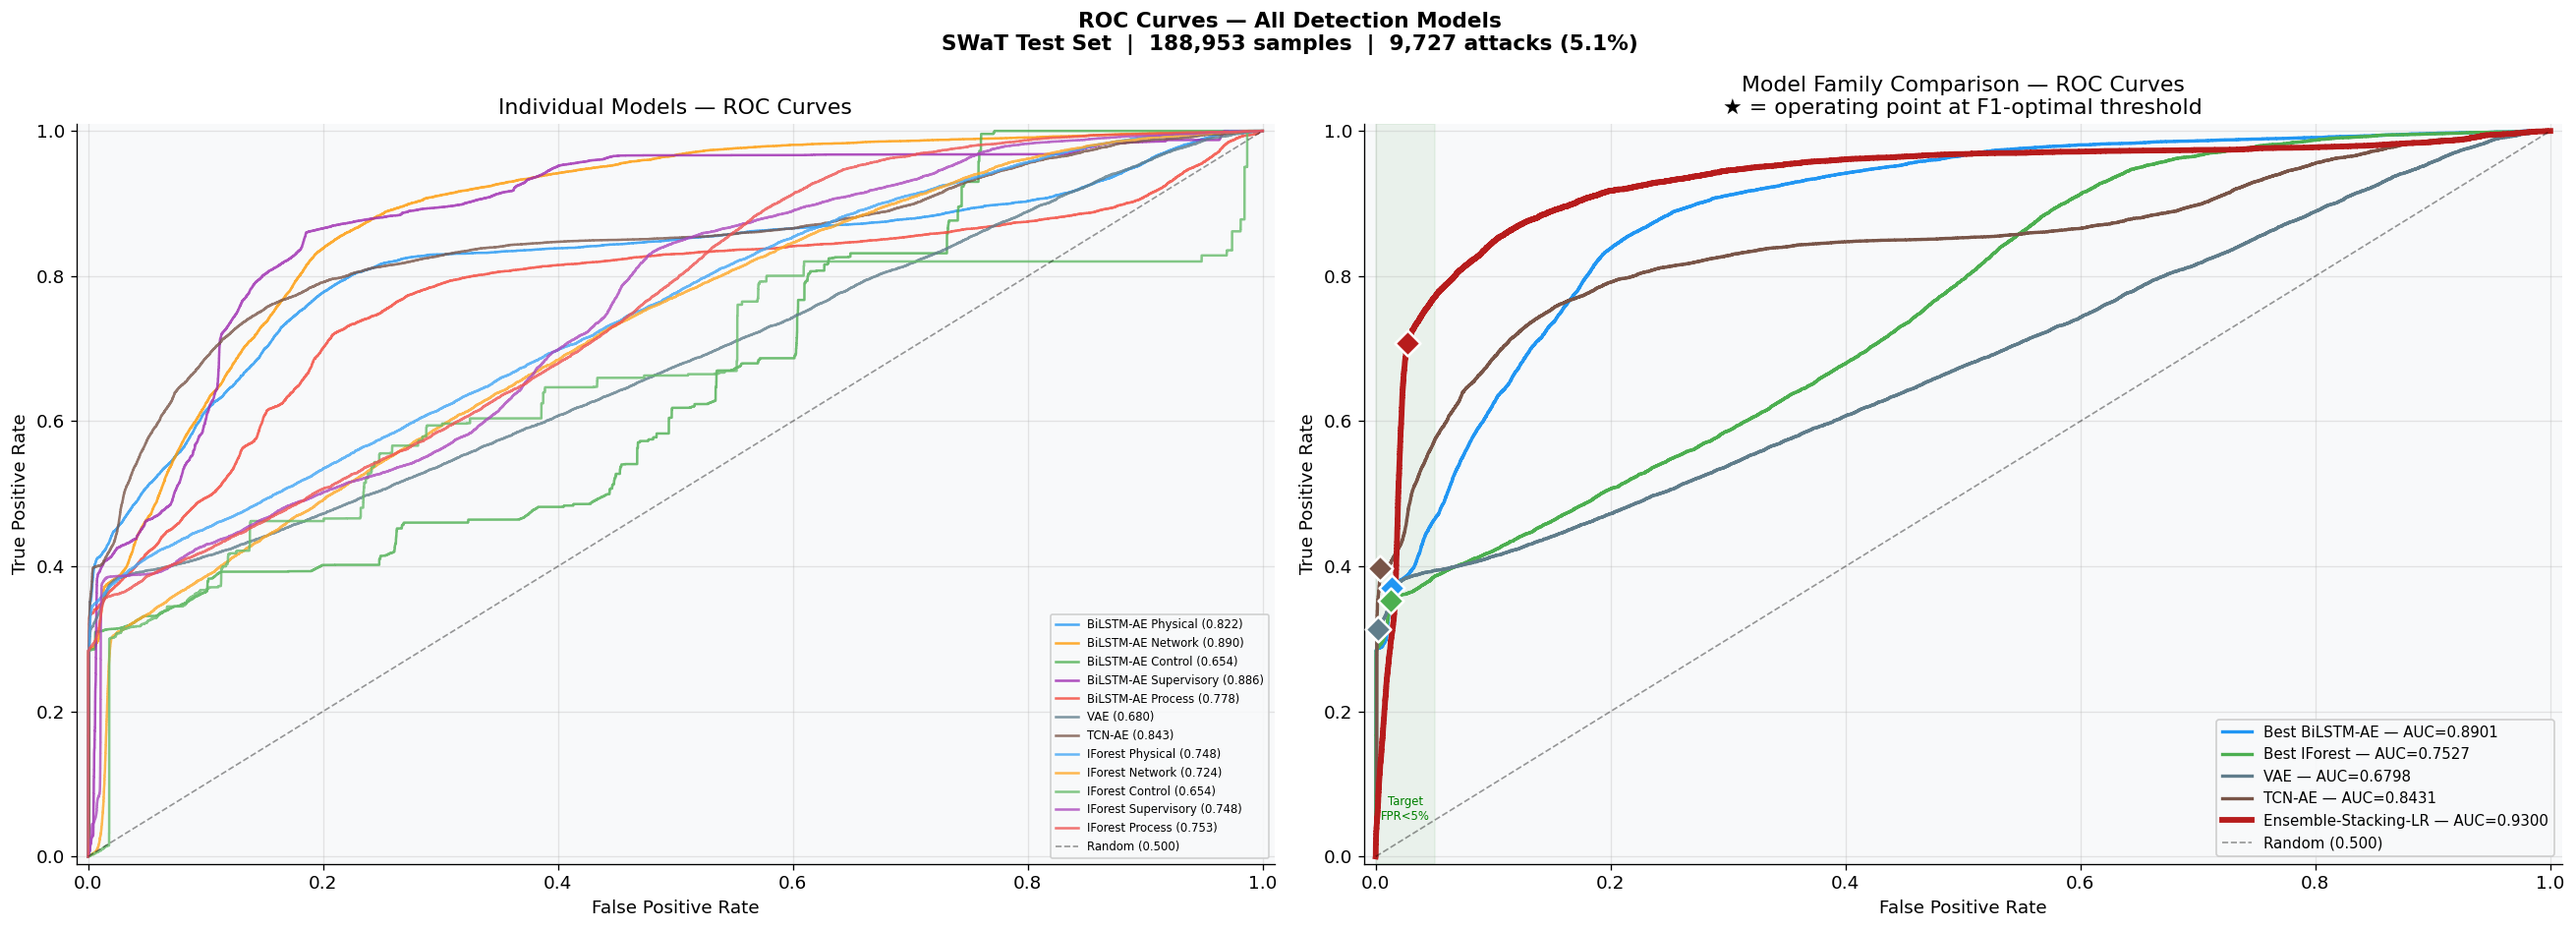

Saved: 18_roc_curves.png


In [4]:
#   CELL 4 — Figure 18: ROC Curves — All Models                  

print('Generating Figure 18 — ROC curves.')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle(
    'ROC Curves — All Detection Models\n'
    f'SWaT Test Set  |  {n_stream:,} samples  |  '
    f'{n_attack:,} attacks ({n_attack/n_stream*100:.1f}%)',
    fontsize=13, fontweight='bold')

# Panel 1: All individual models
ax1 = axes[0]
for name, scores in model_scores.items():
    if 'Ensemble' in name:
        continue
    fpr_c, tpr_c, _ = roc_curve(y_true, scores)
    auc_v            = roc_auc_score(y_true, scores)
    col              = MODEL_COLORS.get(name, '#888888')
    lw               = 1.5
    ax1.plot(fpr_c, tpr_c, color=col, lw=lw, alpha=0.8,
              label=f'{name[:30]} ({auc_v:.3f})')

ax1.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random (0.500)')
ax1.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
         title='Individual Models — ROC Curves')
ax1.legend(fontsize=7, loc='lower right', framealpha=0.9)
ax1.set_xlim(-0.01, 1.01); ax1.set_ylim(-0.01, 1.01)

# Panel 2: Model families + Ensemble (comparison)
ax2 = axes[1]
family_rep = {
    'Best BiLSTM-AE' : max(
        [(n,s) for n,s in model_scores.items() if 'BiLSTM' in n],
        key=lambda x: roc_auc_score(y_true, x[1])
    ),
    'Best IForest'   : max(
        [(n,s) for n,s in model_scores.items() if 'IForest' in n],
        key=lambda x: roc_auc_score(y_true, x[1])
    ),
    'VAE'            : ('VAE', model_scores['VAE']),
    'TCN-AE'         : ('TCN-AE', model_scores['TCN-AE']),
    'Ensemble-Stacking-LR': ('Ensemble-Stacking-LR',
                              model_scores['Ensemble-Stacking-LR']),
}
family_colors = {
    'Best BiLSTM-AE'      : '#2196F3',
    'Best IForest'        : '#4CAF50',
    'VAE'                 : '#607D8B',
    'TCN-AE'              : '#795548',
    'Ensemble-Stacking-LR': '#B71C1C',
}
for label, (name, scores) in family_rep.items():
    fpr_c, tpr_c, _ = roc_curve(y_true, scores)
    auc_v            = roc_auc_score(y_true, scores)
    col              = family_colors[label]
    lw               = 3.5 if 'Ensemble' in label else 2.0
    ls               = '-'
    ax2.plot(fpr_c, tpr_c, color=col, lw=lw, ls=ls,
              label=f'{label} — AUC={auc_v:.4f}')
    # Mark operating point
    r = eval_results[name]
    ax2.scatter(r['fpr'], r['tpr'], color=col, s=120,
                 zorder=5, marker='D',
                 edgecolors='white', linewidths=1.5)

ax2.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random (0.500)')
ax2.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
         title='Model Family Comparison — ROC Curves\n★ = operating point at F1-optimal threshold')
ax2.legend(fontsize=9, loc='lower right', framealpha=0.95)
ax2.set_xlim(-0.01, 1.01); ax2.set_ylim(-0.01, 1.01)

# Shade low-FPR region
ax2.axvspan(0, 0.05, alpha=0.06, color='green')
ax2.text(0.025, 0.05, 'Target\nFPR<5%', ha='center', fontsize=7, color='green')

plt.tight_layout()
plt.savefig(f'{OUT}/figures/18_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 18_roc_curves.png')

Generating Figure 19 — Precision-Recall curves.


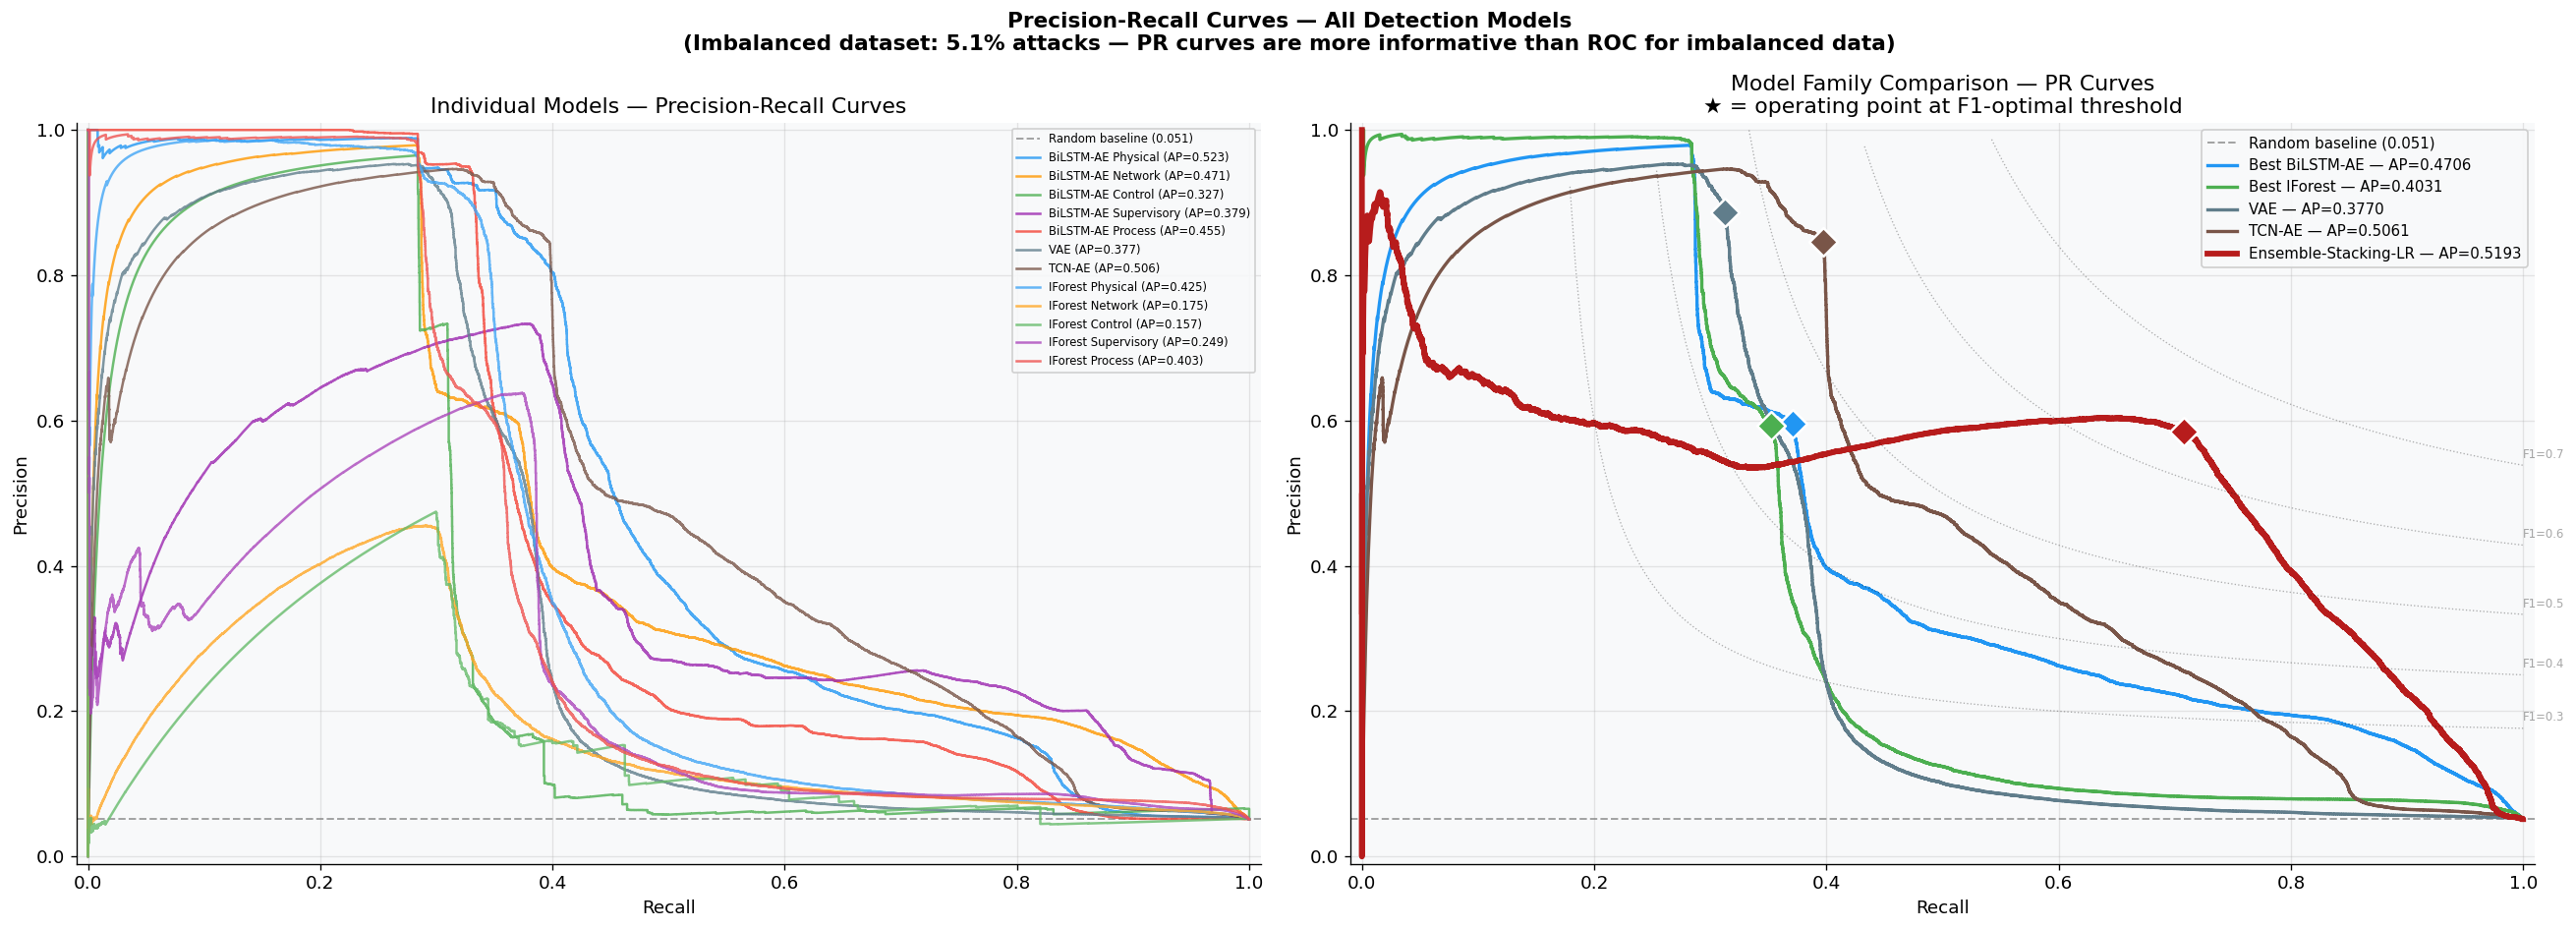

Saved: 19_pr_curves.png


In [5]:
#  CELL 5 — Figure 19: Precision-Recall Curves                  
#  More informative than ROC for imbalanced datasets (5.1% atk) 

print('Generating Figure 19 — Precision-Recall curves.')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle(
    'Precision-Recall Curves — All Detection Models\n'
    f'(Imbalanced dataset: {n_attack/n_stream*100:.1f}% attacks — '
    'PR curves are more informative than ROC for imbalanced data)',
    fontsize=13, fontweight='bold')

# Panel 1: All models
ax1 = axes[0]
baseline = n_attack / n_stream
ax1.axhline(baseline, color='gray', ls='--', lw=1.2,
             label=f'Random baseline ({baseline:.3f})', alpha=0.7)

for name, scores in model_scores.items():
    if 'Ensemble' in name:
        continue
    prec, rec, _ = precision_recall_curve(y_true, scores)
    ap            = average_precision_score(y_true, scores)
    col           = MODEL_COLORS.get(name, '#888888')
    ax1.plot(rec, prec, color=col, lw=1.5, alpha=0.8,
              label=f'{name[:30]} (AP={ap:.3f})')

ax1.set(xlabel='Recall', ylabel='Precision',
         title='Individual Models — Precision-Recall Curves')
ax1.legend(fontsize=7, loc='upper right', framealpha=0.9)
ax1.set_xlim(-0.01, 1.01); ax1.set_ylim(-0.01, 1.01)

# Panel 2: Family comparison with operating points
ax2 = axes[1]
ax2.axhline(baseline, color='gray', ls='--', lw=1.2,
             label=f'Random baseline ({baseline:.3f})', alpha=0.7)

for label, (name, scores) in family_rep.items():
    prec, rec, _ = precision_recall_curve(y_true, scores)
    ap            = average_precision_score(y_true, scores)
    col           = family_colors[label]
    lw            = 3.5 if 'Ensemble' in label else 2.0
    ax2.plot(rec, prec, color=col, lw=lw,
              label=f'{label} — AP={ap:.4f}')
    # Operating point
    r = eval_results[name]
    ax2.scatter(r['recall'], r['precision'], color=col, s=150,
                 zorder=5, marker='D',
                 edgecolors='white', linewidths=1.5)

ax2.set(xlabel='Recall', ylabel='Precision',
         title='Model Family Comparison — PR Curves\n★ = operating point at F1-optimal threshold')
ax2.legend(fontsize=9, loc='upper right', framealpha=0.95)
ax2.set_xlim(-0.01, 1.01); ax2.set_ylim(-0.01, 1.01)

# F1 iso-curves
for f1_val in [0.3, 0.4, 0.5, 0.6, 0.7]:
    x_iso = np.linspace(0.01, 1.0, 200)
    y_iso = f1_val * x_iso / (2 * x_iso - f1_val + 1e-9)
    mask  = (y_iso >= 0) & (y_iso <= 1)
    ax2.plot(x_iso[mask], y_iso[mask], 'k:', lw=0.8, alpha=0.3)
    # label at end of curve
    if mask.sum() > 0:
        ax2.text(x_iso[mask][-1], y_iso[mask][-1] + 0.01,
                  f'F1={f1_val}', fontsize=7, color='gray', alpha=0.7)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/19_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 19_pr_curves.png')

Generating Figure 20 — confusion matrices.


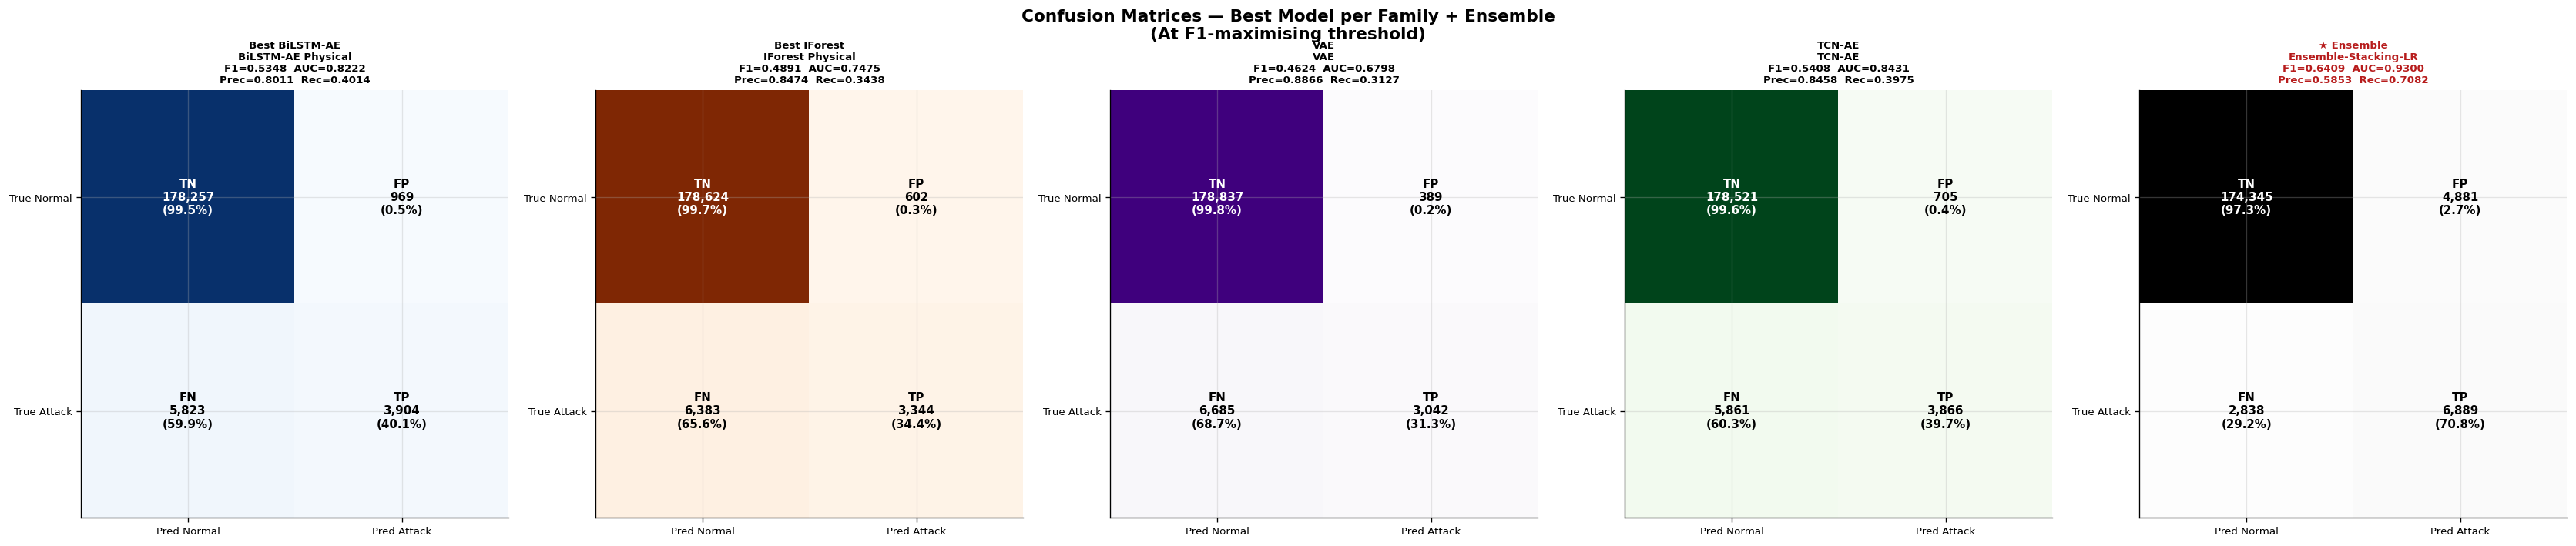

Saved: 20_confusion_matrices.png


In [6]:

#  CELL 6 — Figure 20: Confusion Matrices                       
#  Best per-family model + Ensemble                             

print('Generating Figure 20 — confusion matrices.')

# Select best model per family by F1
families = {
    'Best BiLSTM-AE' : max(
        [n for n in model_scores if 'BiLSTM' in n],
        key=lambda n: eval_results[n]['f1']),
    'Best IForest'   : max(
        [n for n in model_scores if 'IForest' in n],
        key=lambda n: eval_results[n]['f1']),
    'VAE'            : 'VAE',
    'TCN-AE'         : 'TCN-AE',
    '★ Ensemble'     : 'Ensemble-Stacking-LR',
}

fig, axes = plt.subplots(1, 5, figsize=(28, 6))
fig.suptitle(
    'Confusion Matrices — Best Model per Family + Ensemble\n'
    '(At F1-maximising threshold)',
    fontsize=13, fontweight='bold')

cmap_list = ['Blues', 'Oranges', 'Purples', 'Greens', 'Greys']

for ax, (label, name), cmap in zip(axes, families.items(), cmap_list):
    r   = eval_results[name]
    cm  = np.array([[r['tn'], r['fp']],
                     [r['fn'], r['tp']]])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.max())

    # Annotations — count + percentage
    labels_ = [['TN','FP'],['FN','TP']]
    for i in range(2):
        for j in range(2):
            col_ = 'white' if cm[i,j] > cm.max()*0.6 else 'black'
            ax.text(j, i,
                     f'{labels_[i][j]}\n{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                     ha='center', va='center',
                     fontsize=9, fontweight='bold', color=col_)

    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Normal','Pred Attack'], fontsize=8)
    ax.set_yticklabels(['True Normal','True Attack'], fontsize=8)

    res_r = eval_results[name]
    ax.set_title(
        f'{label}\n{name[:28]}\n'
        f'F1={res_r["f1"]:.4f}  AUC={res_r["auc"]:.4f}\n'
        f'Prec={res_r["precision"]:.4f}  Rec={res_r["recall"]:.4f}',
        fontweight='bold', fontsize=8,
        color='#B71C1C' if '★' in label else 'black')

plt.tight_layout()
plt.savefig(f'{OUT}/figures/20_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 20_confusion_matrices.png')

Generating Figure 21 — model comparison.


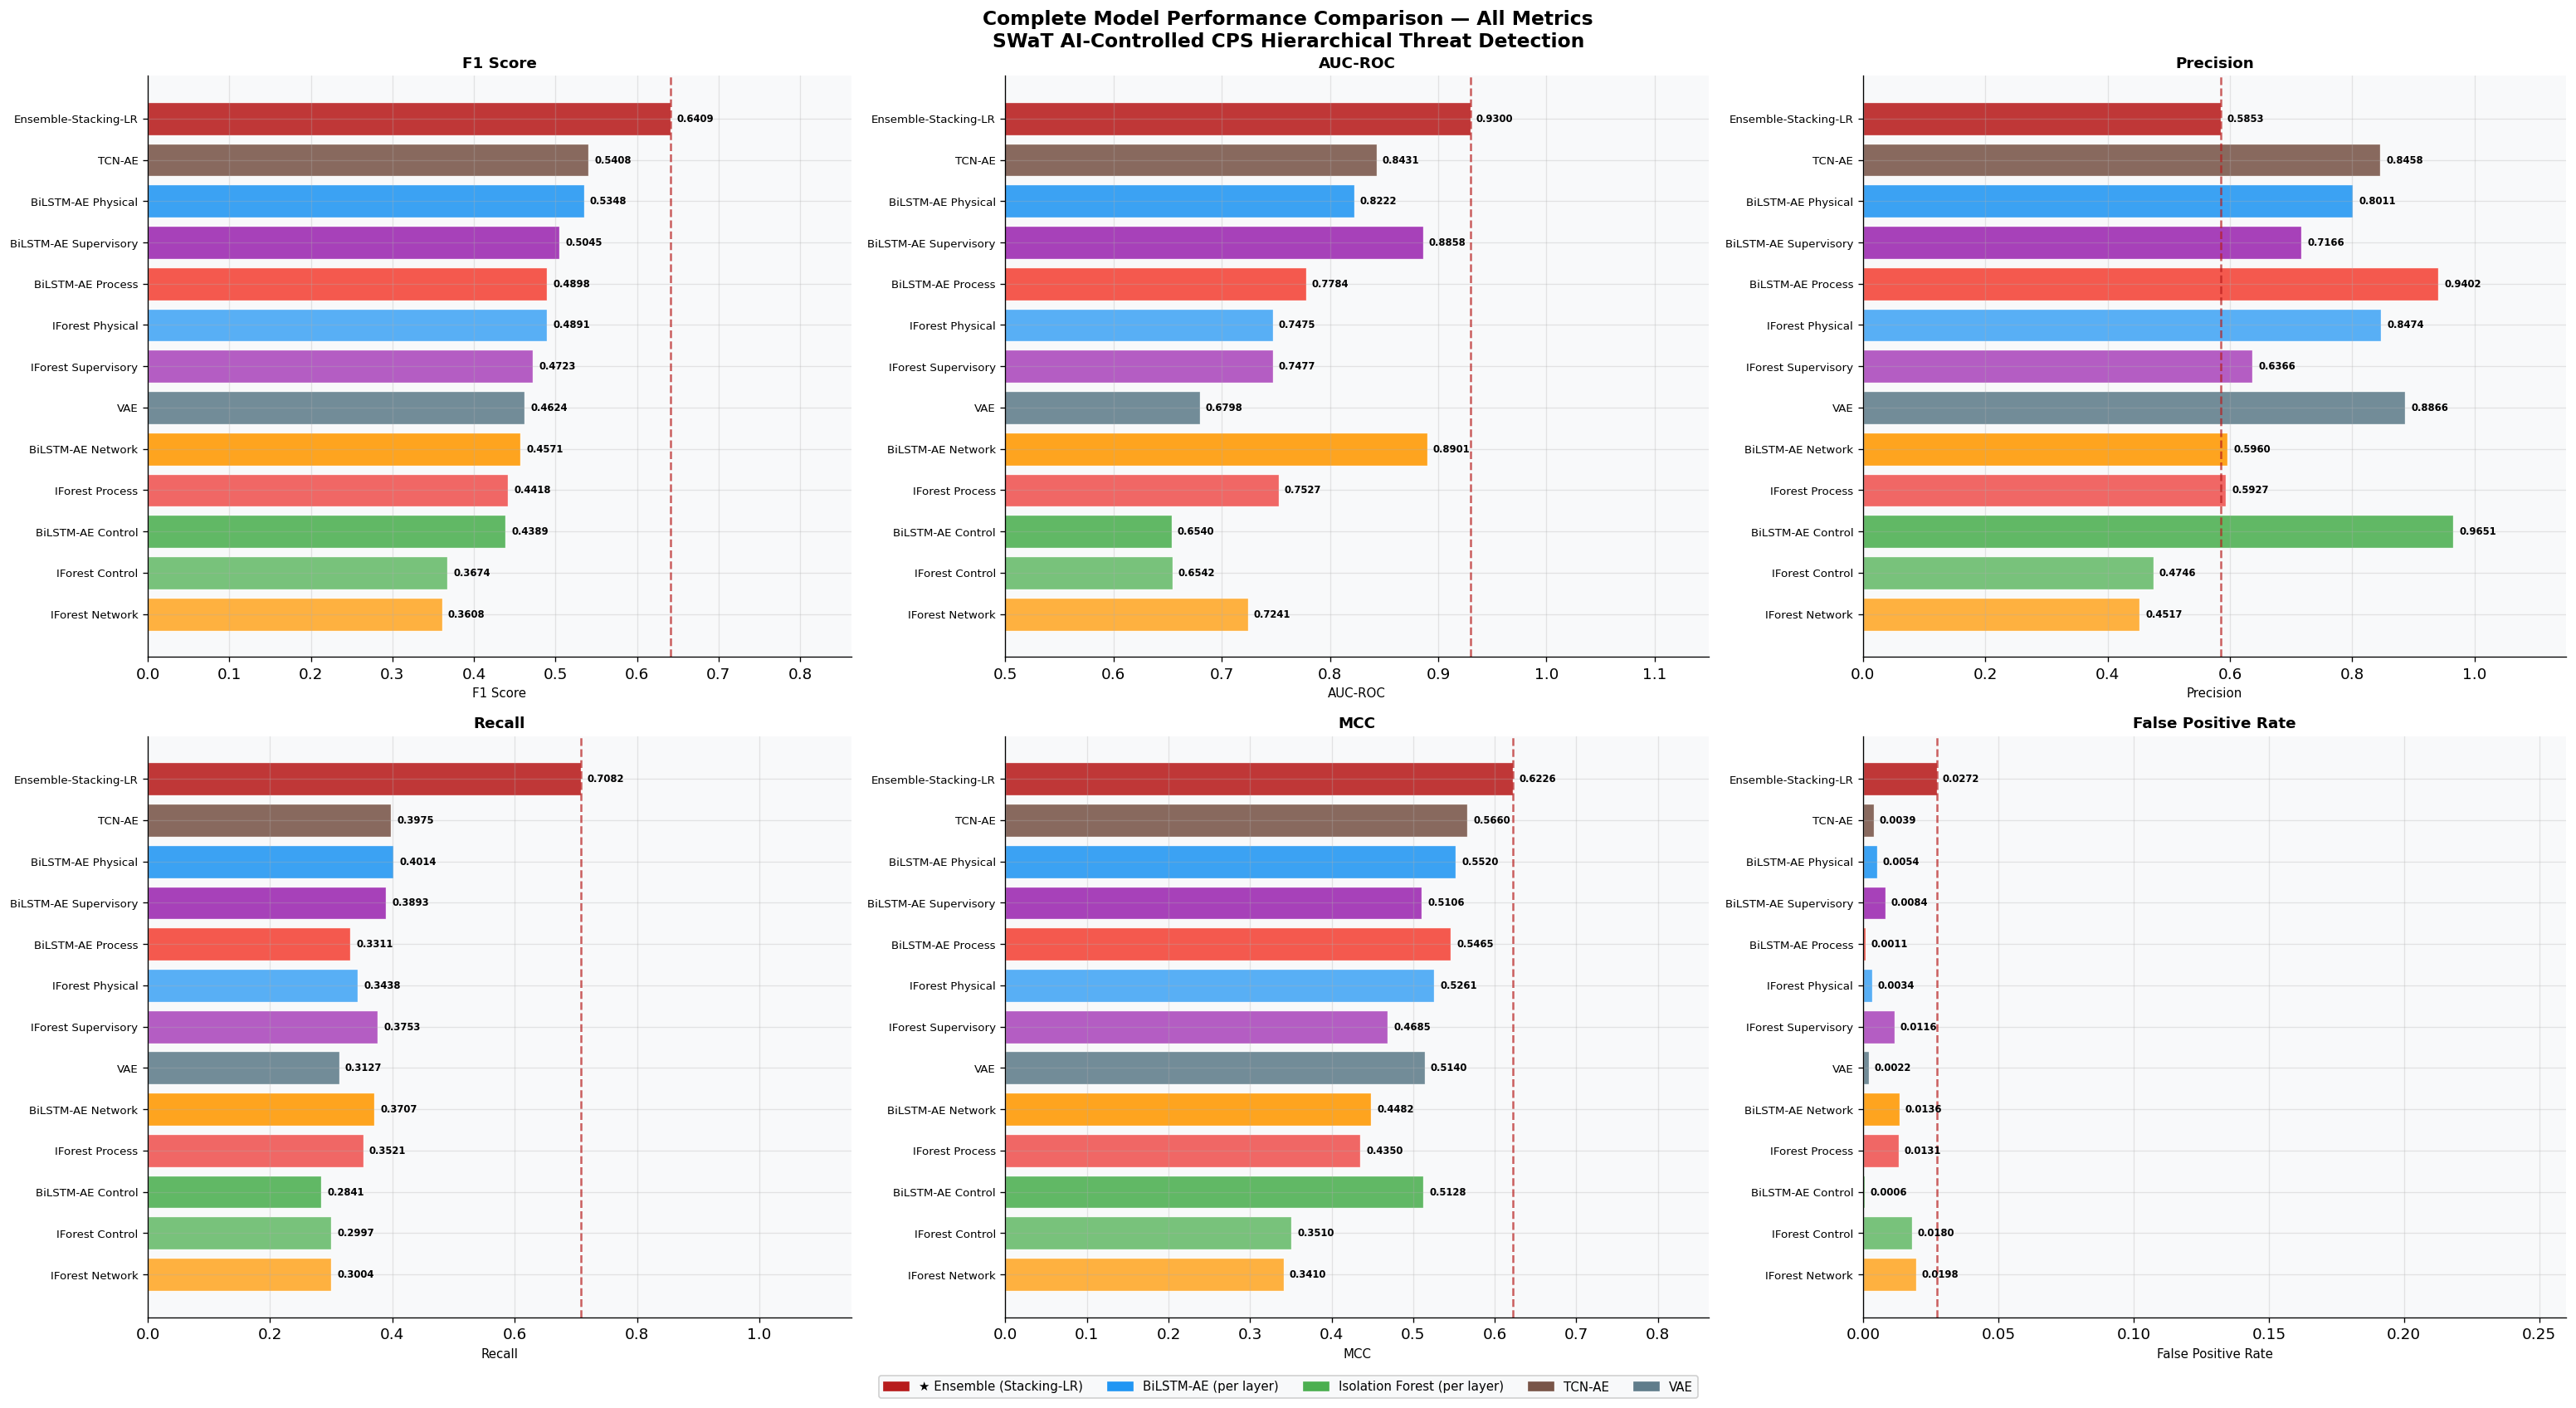

Saved: 21_model_comparison.png


In [7]:
#  CELL 7 — Figure 21: Complete Model Comparison Bar Chart       

print('Generating Figure 21 — model comparison.')

fig, axes = plt.subplots(2, 3, figsize=(26, 14))
fig.suptitle(
    'Complete Model Performance Comparison — All Metrics\n'
    'SWaT AI-Controlled CPS Hierarchical Threat Detection',
    fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('f1',        'F1 Score',             (0, 0.75)),
    ('auc',       'AUC-ROC',              (0.5, 1.0)),
    ('precision', 'Precision',             (0, 1.0)),
    ('recall',    'Recall',                (0, 1.0)),
    ('mcc',       'MCC',                   (0, 0.75)),
    ('fpr',       'False Positive Rate',   (0, 0.20)),
]

sorted_models = eval_df.sort_values('f1', ascending=True)['model'].tolist()

for ax, (metric, label, ylim) in zip(axes.flatten(), metrics_to_plot):
    vals   = [eval_results[m][metric] for m in sorted_models]
    colors = []
    for m in sorted_models:
        if 'Ensemble' in m: colors.append('#B71C1C')
        elif 'BiLSTM' in m: colors.append(MODEL_COLORS.get(m, '#2196F3'))
        elif 'IForest' in m: colors.append(MODEL_COLORS.get(m, '#4CAF50'))
        elif 'TCN' in m:    colors.append('#795548')
        else:               colors.append('#607D8B')  # VAE

    bars = ax.barh(range(len(sorted_models)), vals,
                    color=colors, edgecolor='white', linewidth=0.8,
                    alpha=0.88)
    ax.set_yticks(range(len(sorted_models)))
    ax.set_yticklabels([m[:32] for m in sorted_models], fontsize=8)
    ax.set_xlim(ylim[0], ylim[1] * 1.15 if metric != 'fpr' else ylim[1] * 1.3)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel(label, fontsize=9)

    for bar, val in zip(bars, vals):
        ax.text(val + (ylim[1]-ylim[0])*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=7, fontweight='bold')

    # Ensemble reference line
    ens_val = eval_results['Ensemble-Stacking-LR'][metric]
    ax.axvline(ens_val, color='#B71C1C', lw=1.5, ls='--', alpha=0.7)

# Legend
legend_patches = [
    mpatches.Patch(color='#B71C1C', label='★ Ensemble (Stacking-LR)'),
    mpatches.Patch(color='#2196F3', label='BiLSTM-AE (per layer)'),
    mpatches.Patch(color='#4CAF50', label='Isolation Forest (per layer)'),
    mpatches.Patch(color='#795548', label='TCN-AE'),
    mpatches.Patch(color='#607D8B', label='VAE'),
]
fig.legend(handles=legend_patches, loc='lower center',
            ncol=5, fontsize=9, framealpha=0.9,
            bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f'{OUT}/figures/21_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 21_model_comparison.png')

Generating Figure 22 — per-layer radar chart...


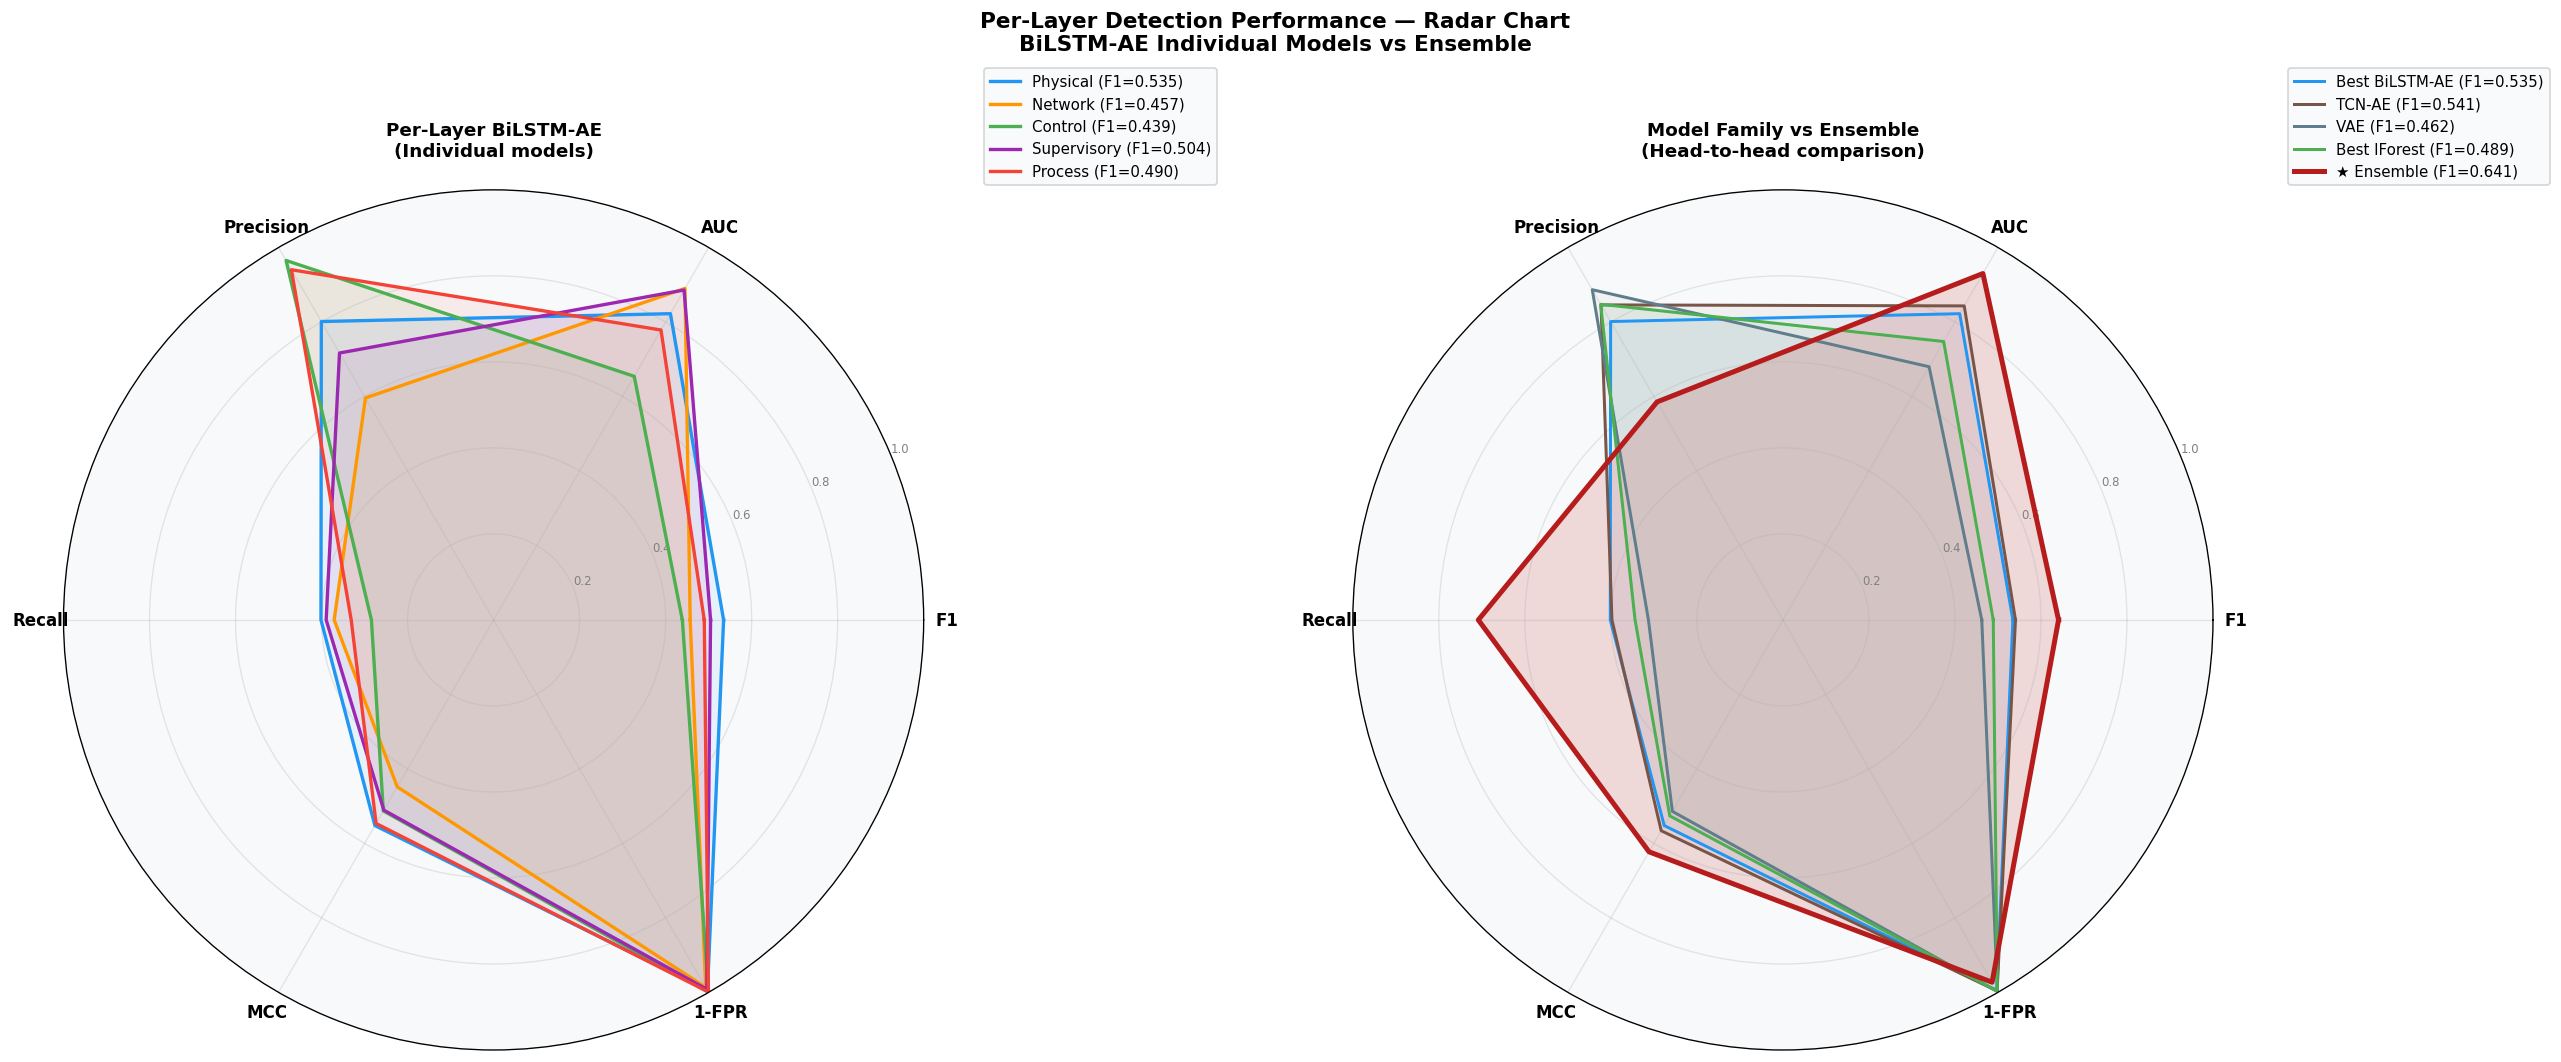

Saved: 22_radar_chart.png


In [8]:
#  CELL 8 — Figure 22: Per-Layer Radar Chart                    
#  F1/AUC/Precision/Recall/MCC per layer — spider plot          

print('Generating Figure 22 — per-layer radar chart...')

# Per-layer BiLSTM metrics
layer_metrics = {}
for layer in LAYERS:
    name = f'BiLSTM-AE {layer.capitalize()}'
    if name in eval_results:
        layer_metrics[layer] = eval_results[name]

# Radar categories
categories  = ['F1', 'AUC', 'Precision', 'Recall', 'MCC', '1-FPR']
metric_keys = ['f1', 'auc', 'precision', 'recall', 'mcc', 'fpr']
N           = len(categories)
angles      = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles     += angles[:1]  # close polygon

fig, axes = plt.subplots(1, 2, figsize=(22, 9),
                          subplot_kw=dict(polar=True))
fig.suptitle(
    'Per-Layer Detection Performance — Radar Chart\n'
    'BiLSTM-AE Individual Models vs Ensemble',
    fontsize=13, fontweight='bold')

# Panel 1: Per-layer individual BiLSTM
ax1 = axes[0]
for layer in LAYERS:
    if layer not in layer_metrics:
        continue
    r     = layer_metrics[layer]
    vals  = [r['f1'], r['auc'], r['precision'],
              r['recall'], r['mcc'], 1-r['fpr']]
    vals += vals[:1]
    col   = LAYER_COLORS[layer]
    ax1.plot(angles, vals, color=col, lw=2.0,
              label=f'{layer.capitalize()} (F1={r["f1"]:.3f})')
    ax1.fill(angles, vals, color=col, alpha=0.08)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax1.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7, color='gray')
ax1.set_title('Per-Layer BiLSTM-AE\n(Individual models)',
               fontweight='bold', pad=20, fontsize=11)
ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

# Panel 2: Best individual per family vs Ensemble
ax2 = axes[1]
families_radar = {
    'Best BiLSTM-AE': max(
        [n for n in eval_results if 'BiLSTM' in n],
        key=lambda n: eval_results[n]['f1']),
    'TCN-AE'        : 'TCN-AE',
    'VAE'           : 'VAE',
    'Best IForest'  : max(
        [n for n in eval_results if 'IForest' in n],
        key=lambda n: eval_results[n]['f1']),
    '★ Ensemble'   : 'Ensemble-Stacking-LR',
}
fam_colors = ['#2196F3','#795548','#607D8B','#4CAF50','#B71C1C']

for (label, name), col in zip(families_radar.items(), fam_colors):
    r     = eval_results[name]
    vals  = [r['f1'], r['auc'], r['precision'],
              r['recall'], r['mcc'], 1-r['fpr']]
    vals += vals[:1]
    lw    = 3.0 if '★' in label else 1.8
    ax2.plot(angles, vals, color=col, lw=lw,
              label=f'{label} (F1={r["f1"]:.3f})')
    ax2.fill(angles, vals, color=col,
              alpha=0.15 if '★' in label else 0.05)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7, color='gray')
ax2.set_title('Model Family vs Ensemble\n(Head-to-head comparison)',
               fontweight='bold', pad=20, fontsize=11)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/22_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 22_radar_chart.png')

Generating Figure 23 — SHAP explainability.


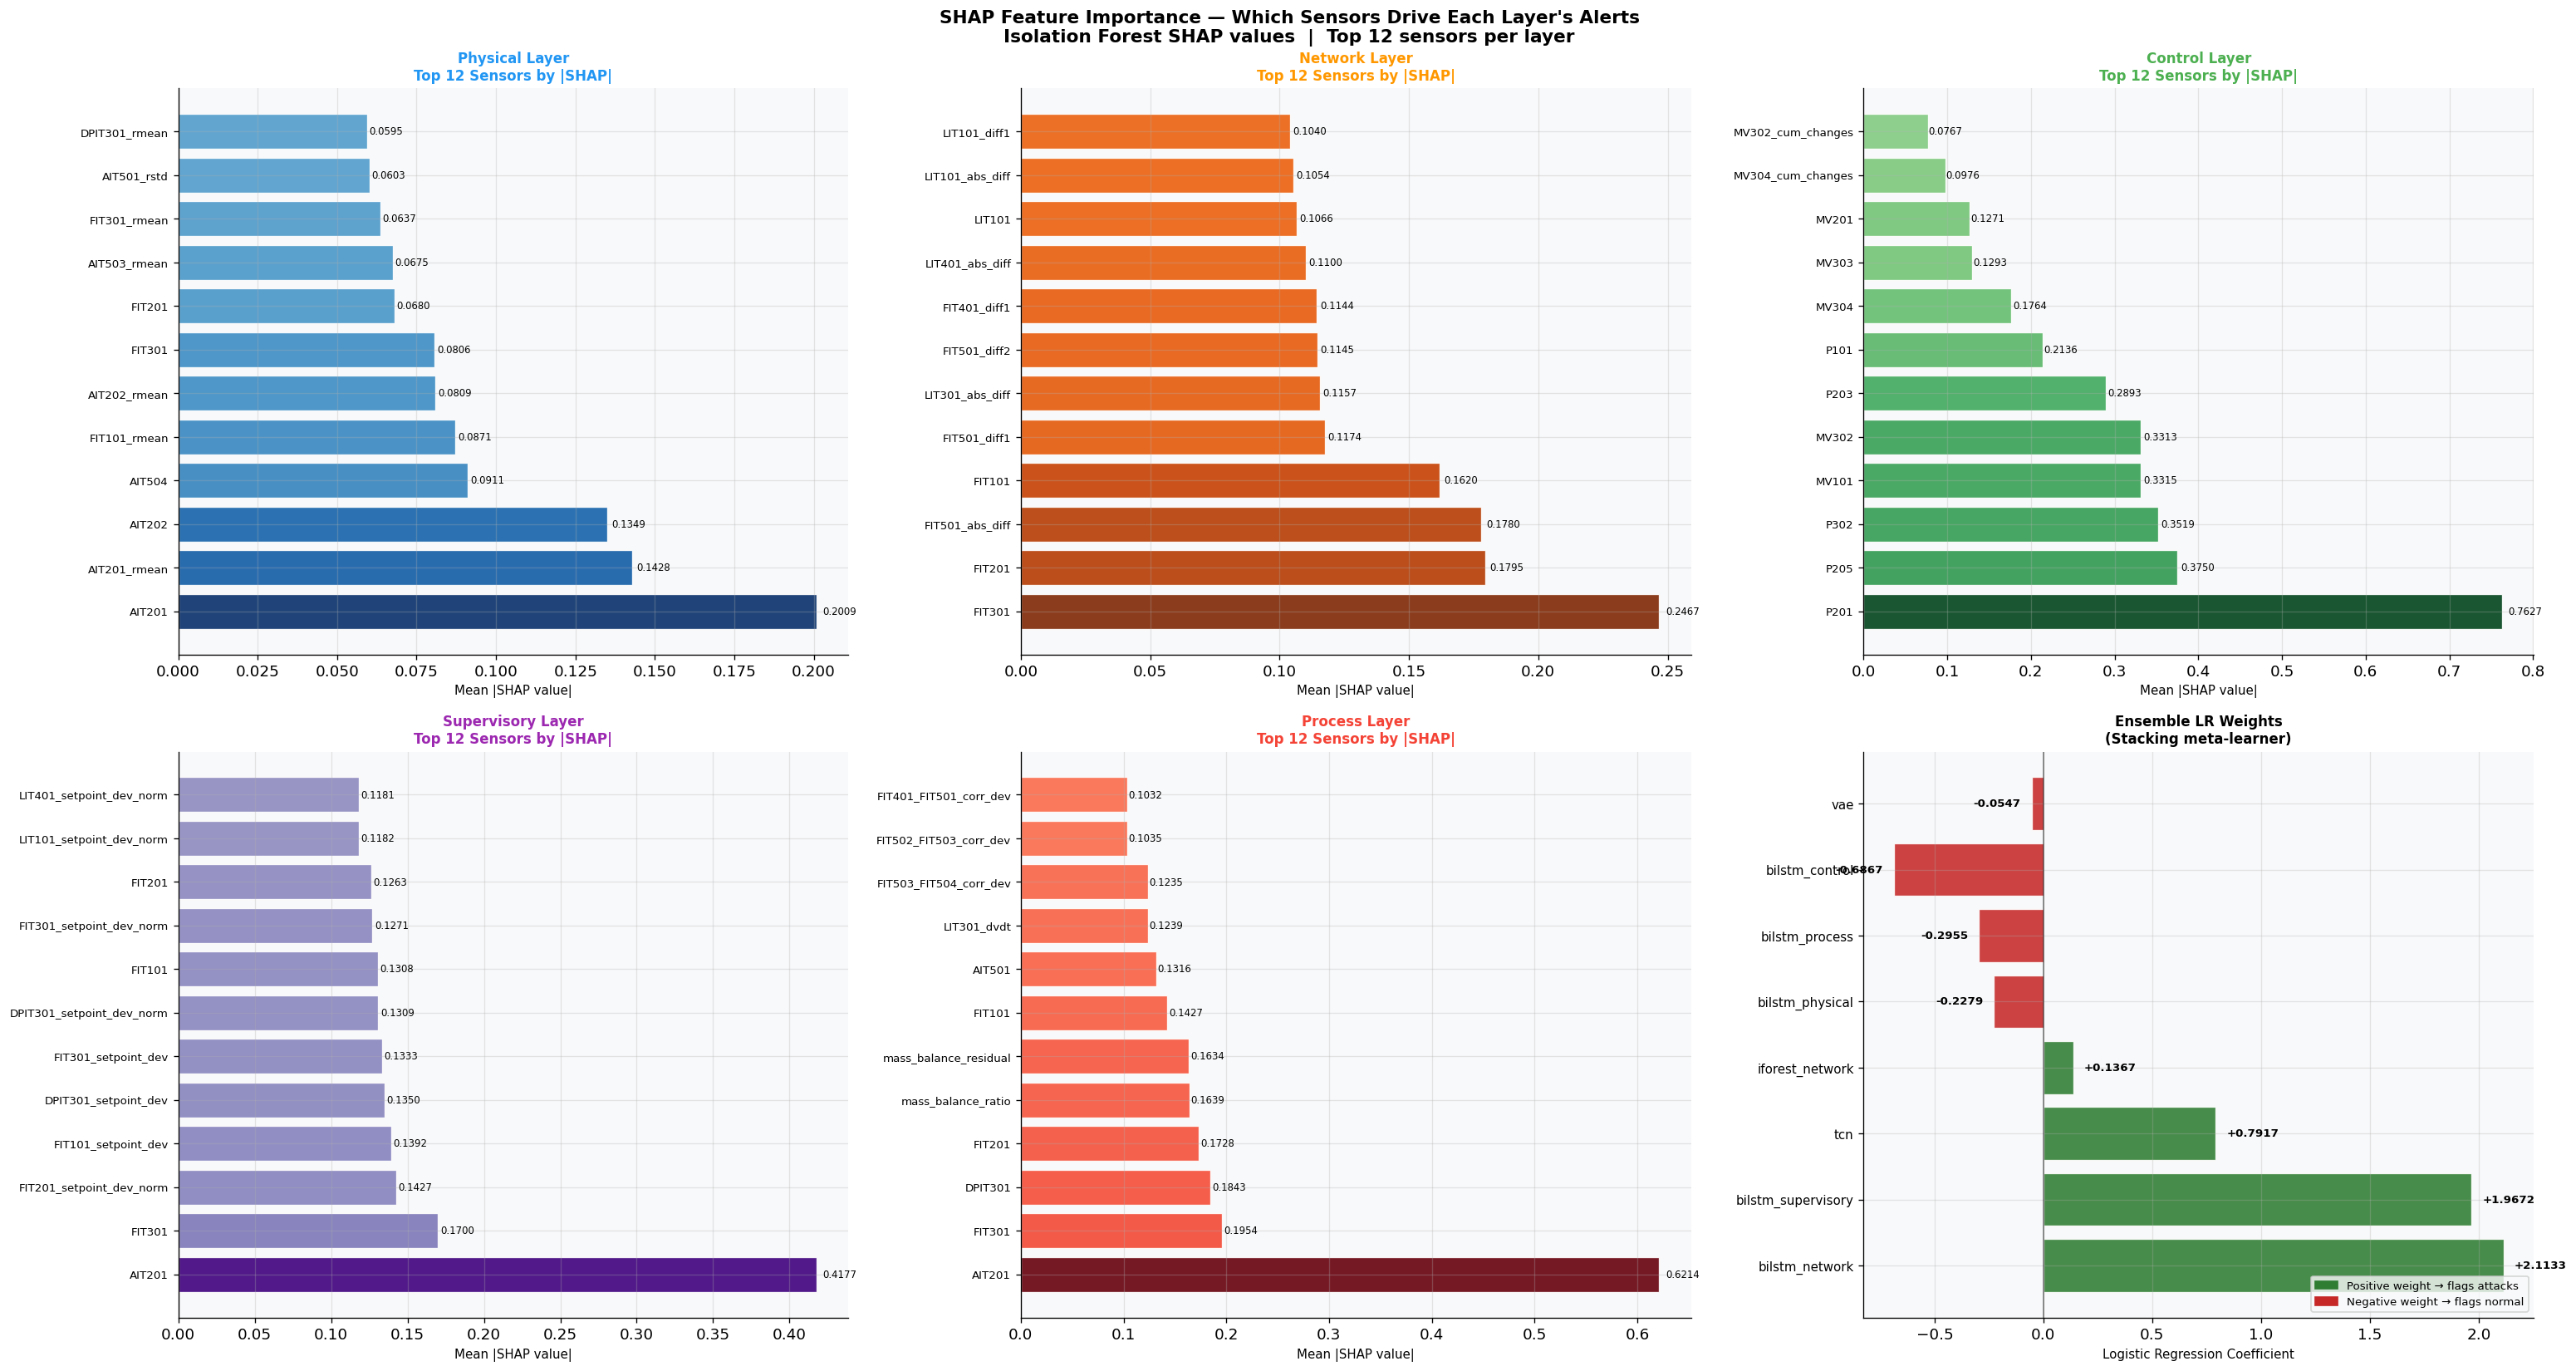

Saved: 23_shap_explainability.png


In [9]:
#  CELL 9 — Figure 23: SHAP Feature Importance per Layer        
#  Which sensors drive each layer's alerts                       

print('Generating Figure 23 — SHAP explainability.')

fig, axes = plt.subplots(2, 3, figsize=(26, 14))
fig.suptitle(
    'SHAP Feature Importance — Which Sensors Drive Each Layer\'s Alerts\n'
    'Isolation Forest SHAP values  |  Top 12 sensors per layer',
    fontsize=13, fontweight='bold')

all_axes  = axes.flatten()
ax_idx    = 0

for layer in LAYERS:
    ax  = all_axes[ax_idx]
    ax_idx += 1
    col = LAYER_COLORS[layer]
    sv  = shap_dict.get(layer)

    if sv is None or not isinstance(sv, dict):
        ax.text(0.5, 0.5, f'SHAP\nN/A\n({layer})',
                ha='center', va='center',
                transform=ax.transAxes, fontsize=14, color='gray')
        ax.set_title(f'{layer.capitalize()} Layer', color=col, fontweight='bold')
        continue

    shap_vals = sv.get('values')
    feat_cols = sv.get('feat_cols', [])

    if shap_vals is None or len(feat_cols) == 0:
        ax.text(0.5, 0.5, 'No SHAP data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(f'{layer.capitalize()} Layer', color=col, fontweight='bold')
        continue

    shap_arr  = np.array(shap_vals)
    mean_abs  = np.abs(shap_arr).mean(axis=0)
    top_n     = min(12, len(mean_abs))
    top_idx   = np.argsort(mean_abs)[-top_n:][::-1]
    top_names = [str(feat_cols[i])[:30] for i in top_idx]
    top_vals  = mean_abs[top_idx]

    # Horizontal bar chart
    y_pos = range(top_n)
    cmap_ = plt.cm.Blues if layer == 'physical' else \
            plt.cm.Oranges if layer == 'network' else \
            plt.cm.Greens if layer == 'control' else \
            plt.cm.Purples if layer == 'supervisory' else plt.cm.Reds

    bar_colors_ = [cmap_(0.4 + 0.6 * v / (top_vals.max() + 1e-9))
                   for v in top_vals]
    bars_ = ax.barh(list(y_pos), top_vals[::-1],
                     color=bar_colors_[::-1],
                     edgecolor='white', linewidth=0.8, alpha=0.9)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_title(f'{layer.capitalize()} Layer\nTop {top_n} Sensors by |SHAP|',
                  fontweight='bold', color=col, fontsize=10)
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)

    for bar, val in zip(bars_, top_vals[::-1]):
        ax.text(val * 1.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=7)

    ax.invert_yaxis()

# Last panel: ensemble contribution
ax_ens = all_axes[ax_idx]
ens_contrib = {}
layer_score_cols = {
    'Physical BiLSTM'    : 'bilstm_physical',
    'Network BiLSTM'     : 'bilstm_network',
    'Control BiLSTM'     : 'bilstm_control',
    'Supervisory BiLSTM' : 'bilstm_supervisory',
    'Process BiLSTM'     : 'bilstm_process',
    'VAE'                : 'vae',
    'TCN-AE'             : 'tcn',
}
# LR feature weights from Phase 3
lr_weights = {
    'bilstm_network'     :  2.1133,
    'bilstm_supervisory' :  1.9672,
    'tcn'                :  0.7917,
    'iforest_network'    :  0.1367,
    'bilstm_physical'    : -0.2279,
    'bilstm_process'     : -0.2955,
    'bilstm_control'     : -0.6867,
    'vae'                : -0.0547,
}
names_w = list(lr_weights.keys())
vals_w  = list(lr_weights.values())
colors_w = ['#2E7D32' if v > 0 else '#C62828' for v in vals_w]

ax_ens.barh(range(len(names_w)), vals_w, color=colors_w,
             edgecolor='white', linewidth=0.8, alpha=0.88)
ax_ens.set_yticks(range(len(names_w)))
ax_ens.set_yticklabels(names_w, fontsize=9)
ax_ens.axvline(0, color='black', lw=1.0, alpha=0.5)
ax_ens.set_title('Ensemble LR Weights\n(Stacking meta-learner)',
                  fontweight='bold', color='black', fontsize=10)
ax_ens.set_xlabel('Logistic Regression Coefficient', fontsize=9)
for i, (v, name) in enumerate(zip(vals_w, names_w)):
    ax_ens.text(v + (0.05 if v>=0 else -0.05), i,
                 f'{v:+.4f}', va='center', fontsize=8,
                 ha='left' if v>=0 else 'right', fontweight='bold')

pos_patch = mpatches.Patch(color='#2E7D32', label='Positive weight → flags attacks')
neg_patch = mpatches.Patch(color='#C62828', label='Negative weight → flags normal')
ax_ens.legend(handles=[pos_patch, neg_patch], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUT}/figures/23_shap_explainability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 23_shap_explainability.png')

Generating Figure 24 — full pipeline summary.


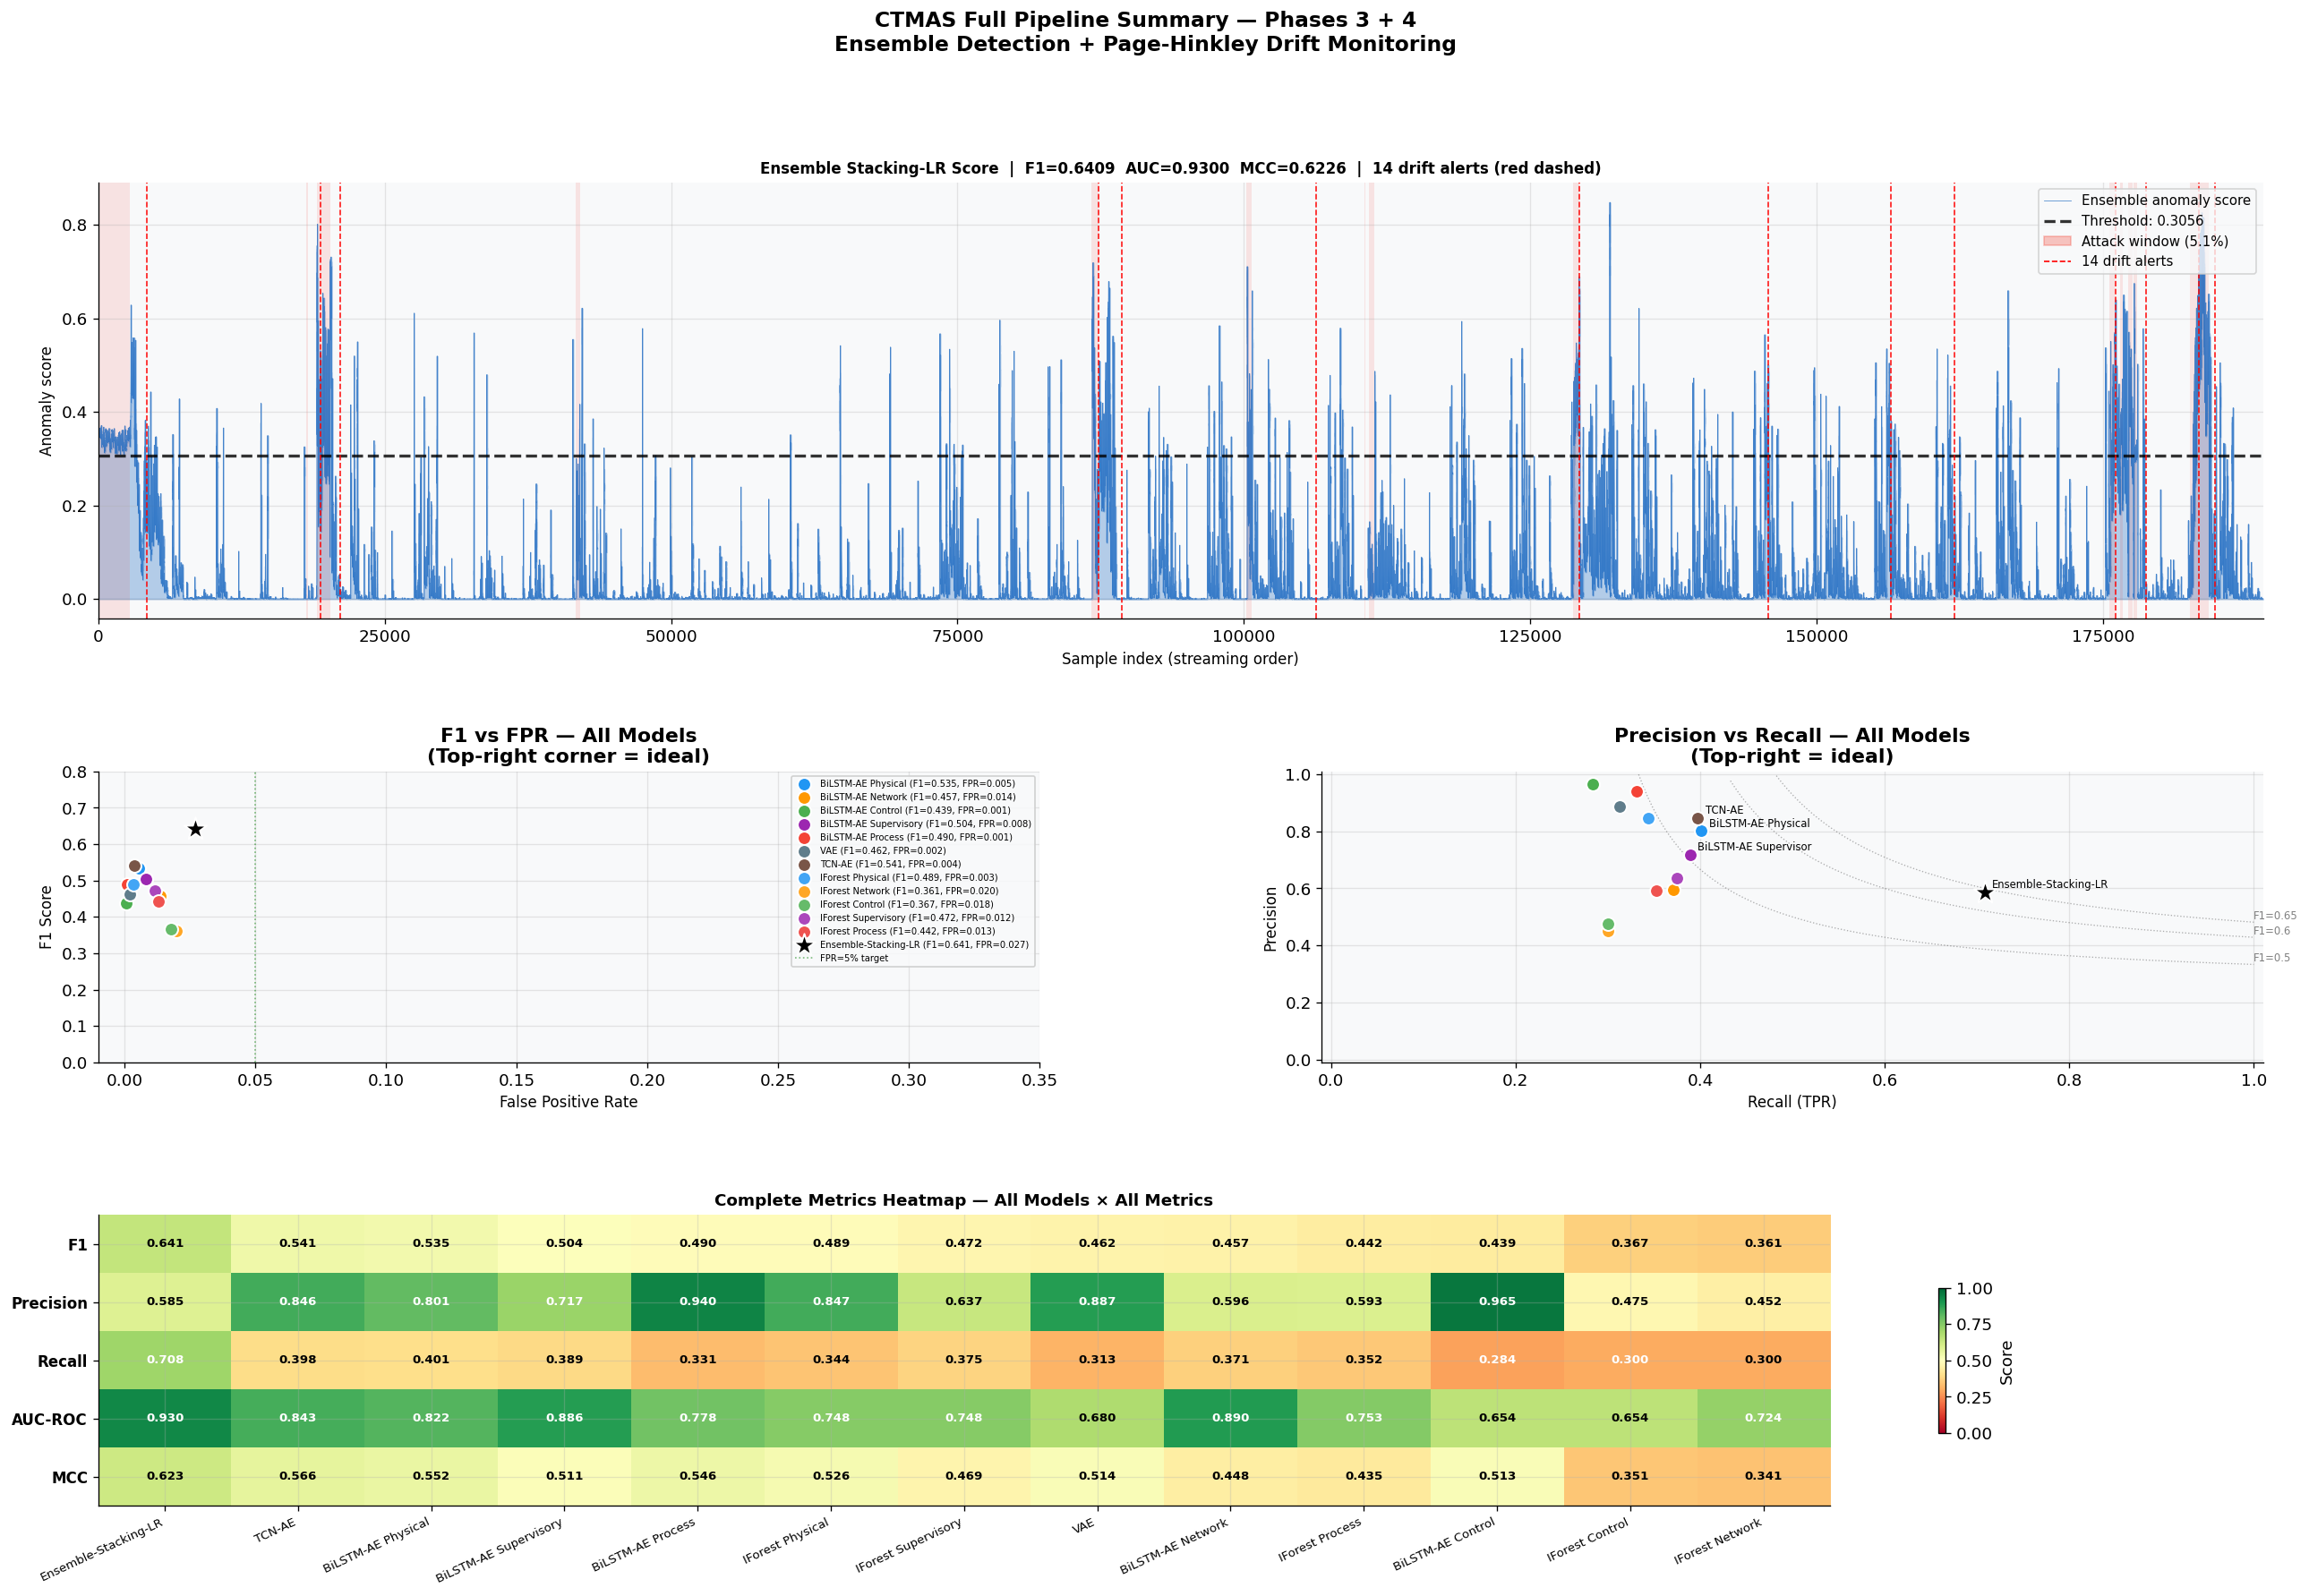

Saved: 24_pipeline_summary.png


In [10]:
#  CELL 10 — Figure 24: Full Pipeline Summary + Drift           
#  Ensemble score + drift alerts + detection performance         

print('Generating Figure 24 — full pipeline summary.')

drift_positions = drift_df['sample_idx'].tolist() \
    if 'sample_idx' in drift_df.columns \
    else P4_CFG.get('drift_events_list', [])

fig = plt.figure(figsize=(26, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig,
                         height_ratios=[1.5, 1, 1],
                         hspace=0.45, wspace=0.3)
fig.suptitle(
    'CTMAS Full Pipeline Summary — Phases 3 + 4\n'
    'Ensemble Detection + Page-Hinkley Drift Monitoring',
    fontsize=14, fontweight='bold')

# Panel 1 (top, full width): Ensemble score timeline
ax1 = fig.add_subplot(gs[0, :])
x   = np.arange(n_stream)
ax1.fill_between(x, ensemble_score, alpha=0.3, color='#1565C0')
ax1.plot(x, ensemble_score, color='#1565C0', lw=0.5, alpha=0.7,
          label='Ensemble anomaly score')
ax1.axhline(P3_CFG['ensemble_threshold'], color='black', ls='--', lw=2.0,
             alpha=0.8, label=f'Threshold: {P3_CFG["ensemble_threshold"]:.4f}')

# Attack windows
atk_    = y_true; in_atk_=False; start_=0
for i_a in range(len(atk_)):
    if atk_[i_a]==1 and not in_atk_: start_=i_a; in_atk_=True
    elif atk_[i_a]==0 and in_atk_:
        ax1.axvspan(start_, i_a, alpha=0.12, color='#F44336', lw=0)
        in_atk_ = False
if in_atk_: ax1.axvspan(start_, len(atk_)-1, alpha=0.12, color='#F44336', lw=0)

# Drift alerts
for ev in drift_positions:
    ax1.axvline(ev, color='red', lw=1.0, alpha=0.9, ls='--')

ax1.set_xlim(0, n_stream)
ax1.set_xlabel('Sample index (streaming order)', fontsize=10)
ax1.set_ylabel('Anomaly score', fontsize=10)
ax1.set_title(
    f'Ensemble Stacking-LR Score  |  '
    f'F1={P3_CFG["final_f1"]:.4f}  AUC={P3_CFG["final_auc"]:.4f}  '
    f'MCC={P3_CFG["final_mcc"]:.4f}  |  '
    f'{P4_CFG["total_drift_events"]} drift alerts (red dashed)',
    fontweight='bold', fontsize=10)

red_patch  = mpatches.Patch(color='#F44336', alpha=0.3, label='Attack window (5.1%)')
drift_line = plt.Line2D([0],[0], color='red', ls='--', lw=1.0,
                          label=f'{P4_CFG["total_drift_events"]} drift alerts')
ax1.legend(handles=[ax1.get_lines()[0], ax1.get_lines()[1],
                     red_patch, drift_line],
            fontsize=9, loc='upper right')

# Panel 2 (middle left): F1 vs FPR scatter
ax2 = fig.add_subplot(gs[1, 0])
for name, r in eval_results.items():
    col  = MODEL_COLORS.get(name, '#888888')
    size = 250 if 'Ensemble' in name else 80
    mk   = '★' if 'Ensemble' in name else 'o'
    ax2.scatter(r['fpr'], r['f1'], c=col, s=size,
                 marker='*' if 'Ensemble' in name else 'o',
                 edgecolors='white', linewidths=1.2,
                 zorder=5 if 'Ensemble' in name else 3,
                 label=f'{name[:28]} (F1={r["f1"]:.3f}, FPR={r["fpr"]:.3f})')

ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('F1 Score', fontsize=10)
ax2.set_title('F1 vs FPR — All Models\n(Top-right corner = ideal)',
               fontweight='bold')
ax2.set_xlim(-0.01, 0.35); ax2.set_ylim(0, 0.80)
ax2.axvline(0.05, color='green', ls=':', lw=1.0, alpha=0.5,
             label='FPR=5% target')
ax2.legend(fontsize=6, loc='upper right', framealpha=0.9)

# Panel 3 (middle right): Recall vs Precision scatter
ax3 = fig.add_subplot(gs[1, 1])
for name, r in eval_results.items():
    col = MODEL_COLORS.get(name, '#888888')
    ax3.scatter(r['recall'], r['precision'], c=col,
                 s=250 if 'Ensemble' in name else 80,
                 marker='*' if 'Ensemble' in name else 'o',
                 edgecolors='white', linewidths=1.2,
                 zorder=5 if 'Ensemble' in name else 3)
    if 'Ensemble' in name or r['f1'] > 0.50:
        ax3.annotate(name[:20],
                      (r['recall'], r['precision']),
                      textcoords='offset points',
                      xytext=(5, 3), fontsize=7)

ax3.set_xlabel('Recall (TPR)', fontsize=10)
ax3.set_ylabel('Precision', fontsize=10)
ax3.set_title('Precision vs Recall — All Models\n(Top-right = ideal)',
               fontweight='bold')
ax3.set_xlim(-0.01, 1.01); ax3.set_ylim(-0.01, 1.01)

# F1 iso-curve for context
x_iso = np.linspace(0.01, 1.0, 200)
for f1_v in [0.5, 0.6, 0.65]:
    y_iso = f1_v * x_iso / (2*x_iso - f1_v + 1e-9)
    mask  = (y_iso>=0) & (y_iso<=1)
    ax3.plot(x_iso[mask], y_iso[mask], 'k:', lw=0.8, alpha=0.3)
    ax3.text(x_iso[mask][-1], y_iso[mask][-1]+0.01,
              f'F1={f1_v}', fontsize=7, color='gray')

# Panel 4 (bottom, full width): Per-model metric heatmap
ax4 = fig.add_subplot(gs[2, :])
heatmap_models = eval_df.sort_values('f1', ascending=False)['model'].tolist()
heatmap_metrics = ['f1','precision','recall','auc','mcc']
heatmap_labels  = ['F1','Precision','Recall','AUC-ROC','MCC']
heat_data = np.array([
    [eval_results[m][k] for k in heatmap_metrics]
    for m in heatmap_models
])
im = ax4.imshow(heat_data.T, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax4, shrink=0.5, label='Score')
for i, metric in enumerate(heatmap_metrics):
    for j, model in enumerate(heatmap_models):
        v   = eval_results[model][metric]
        col_= 'white' if v > 0.7 or v < 0.3 else 'black'
        ax4.text(j, i, f'{v:.3f}', ha='center', va='center',
                  fontsize=8, fontweight='bold', color=col_)
ax4.set_xticks(range(len(heatmap_models)))
ax4.set_xticklabels([m[:22] for m in heatmap_models],
                     rotation=25, ha='right', fontsize=8)
ax4.set_yticks(range(len(heatmap_labels)))
ax4.set_yticklabels(heatmap_labels, fontsize=10, fontweight='bold')
ax4.set_title('Complete Metrics Heatmap — All Models × All Metrics',
               fontweight='bold', fontsize=11)

plt.savefig(f'{OUT}/figures/24_pipeline_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 24_pipeline_summary.png')

In [11]:
#  CELL 11 — Save All Phase 5 Outputs                           

P = f'{OUT}/processed'

# 1. Complete evaluation table
eval_df.drop(columns=['preds'] if 'preds' in eval_df.columns else [], errors='ignore')
eval_df.to_csv(f'{P}/evaluation_results.csv', index=False)
print(f'Yes evaluation_results.csv    → {len(eval_df)} models × {len(eval_df.columns)} metrics')

# 2. Per-layer metrics
layer_eval_rows = []
for layer in LAYERS:
    name = f'BiLSTM-AE {layer.capitalize()}'
    if name in eval_results:
        r = eval_results[name].copy()
        r.pop('preds', None)
        r['layer'] = layer
        layer_eval_rows.append(r)
pd.DataFrame(layer_eval_rows).to_csv(f'{P}/per_layer_evaluation.csv', index=False)
print(f'Yes per_layer_evaluation.csv  → {len(layer_eval_rows)} layers')

# 3. Phase 5 config
ens_r   = eval_results['Ensemble-Stacking-LR']
p5_config = {
    'phase'                     : 5,
    'n_models_evaluated'        : len(eval_results),
    'n_samples'                 : int(n_stream),
    'n_attacks'                 : int(n_attack),
    'attack_rate_pct'           : round(n_attack/n_stream*100, 3),
    'ensemble_f1'               : float(ens_r['f1']),
    'ensemble_auc'              : float(ens_r['auc']),
    'ensemble_precision'        : float(ens_r['precision']),
    'ensemble_recall'           : float(ens_r['recall']),
    'ensemble_mcc'              : float(ens_r['mcc']),
    'ensemble_fpr'              : float(ens_r['fpr']),
    'ensemble_tpr'              : float(ens_r['tpr']),
    'ensemble_tp'               : int(ens_r['tp']),
    'ensemble_tn'               : int(ens_r['tn']),
    'ensemble_fp'               : int(ens_r['fp']),
    'ensemble_fn'               : int(ens_r['fn']),
    'best_individual_f1'        : float(indiv_df['f1'].max()),
    'best_individual_model'     : str(indiv_df.loc[indiv_df['f1'].idxmax(), 'model']),
    'ensemble_improvement_pts'  : round(float(ens_r['f1'] - indiv_df['f1'].max())*100, 2),
    'drift_events_correlated'   : P4_CFG['total_drift_events'],
    'figures_saved'             : [
        '18_roc_curves.png', '19_pr_curves.png',
        '20_confusion_matrices.png', '21_model_comparison.png',
        '22_radar_chart.png', '23_shap_explainability.png',
        '24_pipeline_summary.png',
    ],
}
with open(f'{P}/phase5_config.json', 'w') as f:
    json.dump(p5_config, f, indent=2)
print(f'Yes phase5_config.json        → saved')

print()
print('='*70)
print('  PHASE 5 COMPLETE — EVALUATION + EXPLAINABILITY')
print('='*70)
print()
print(f'  Models evaluated  : {len(eval_results)}')
print(f'  Test samples      : {n_stream:,}')
print(f'  Attack samples    : {n_attack:,} ({n_attack/n_stream*100:.1f}%)')
print()
print(f'  {"Model":<30}  {"F1":>7}  {"AUC":>7}  {"MCC":>7}  {"FPR":>7}')
print('  ' + '-'*60)
for _, row in eval_df.iterrows():
    marker = '  ★' if 'Ensemble' in row['model'] else '   '
    print(f'{marker}  {row["model"]:<30}  {row["f1"]:>7.4f}  '
          f'{row["auc"]:>7.4f}  {row["mcc"]:>7.4f}  {row["fpr"]:>7.4f}')
print()
print(f'  Ensemble improvement over best individual:')
print(f'    +{p5_config["ensemble_improvement_pts"]:.1f} F1 points')
print(f'    Best individual: {p5_config["best_individual_model"]}')
print()
print('  Figures:  18–24')
print('  Files:    evaluation_results.csv, per_layer_evaluation.csv,')
print('            phase5_config.json')
print()

Yes evaluation_results.csv    → 13 models × 15 metrics
Yes per_layer_evaluation.csv  → 5 layers
Yes phase5_config.json        → saved

  PHASE 5 COMPLETE — EVALUATION + EXPLAINABILITY

  Models evaluated  : 13
  Test samples      : 188,953
  Attack samples    : 9,727 (5.1%)

  Model                                F1      AUC      MCC      FPR
  ------------------------------------------------------------
  ★  Ensemble-Stacking-LR             0.6409   0.9300   0.6226   0.0272
     TCN-AE                           0.5408   0.8431   0.5660   0.0039
     BiLSTM-AE Physical               0.5348   0.8222   0.5520   0.0054
     BiLSTM-AE Supervisory            0.5045   0.8858   0.5106   0.0084
     BiLSTM-AE Process                0.4898   0.7784   0.5465   0.0011
     IForest Physical                 0.4891   0.7475   0.5261   0.0034
     IForest Supervisory              0.4723   0.7477   0.4685   0.0116
     VAE                              0.4624   0.6798   0.5140   0.0022
     BiLSTM-AE N